In [1]:
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Pipeline Modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
from google.colab import files

uploaded = files.upload()

Saving statlog+german+credit+data (1).zip to statlog+german+credit+data (1).zip


In [18]:
import zipfile
import os

zip_file = "/content/statlog+german+credit+data (1).zip"
extract_folder = "/content/german_credit"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")
print(os.listdir(extract_folder))

Dataset extracted successfully!
['german.data', 'german.data-numeric', 'german.doc', 'Index']


In [19]:
import os

for root, dirs, files in os.walk("/content/german_credit"):
    for file in files:
        print(os.path.join(root, file))

/content/german_credit/german.data
/content/german_credit/german.data-numeric
/content/german_credit/german.doc
/content/german_credit/Index


In [20]:
zip_filename = 'statlog+german+credit+data (1).zip'
extracted_dir = 'german_credit_data'

# Extract the ZIP archive if present
if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extracted_dir)
    print("Extracted files:", os.listdir(extracted_dir))
    data_path = os.path.join(extracted_dir, 'german.data')
else:
    # Direct fallback if uploaded without zip
    data_path = 'german.data'

# Define official column names (20 features + 1 target)
column_names = [
    'account_status', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings', 'employment_duration', 'installment_rate',
    'personal_status_sex', 'other_debtors', 'present_residence_since',
    'property', 'age', 'other_installment_plans', 'housing',
    'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'target'
]

# Load space-delimited file into pandas
df = pd.read_csv(data_path, sep=r'\s+', names=column_names)

print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Extracted files: ['german.data', 'german.data-numeric', 'german.doc', 'Index']
Dataset shape: 1000 rows and 21 columns.


,account_status,duration_months,credit_history,purpose,credit_amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,liable_people,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print(f"\n--- Duplicate Rows ---: {df.duplicated().sum()}")

print("\n--- Numerical Summary ---")
display(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   account_status           1000 non-null   object
 1   duration_months          1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence_since  1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                

,duration_months,credit_amount,installment_rate,present_residence_since,age,existing_credits,liable_people,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [7]:
# Convert 1 -> 1 (Good Credit) and 2 -> 0 (Bad Credit)
df['target'] = df['target'].map({1: 1, 2: 0})

print("Target Class Counts:")
print(df['target'].value_counts())
print("\nTarget Class Proportions:")
print(df['target'].value_counts(normalize=True))

Target Class Counts:
target
1    700
0    300
Name: count, dtype: int64

Target Class Proportions:
target
1    0.7
0    0.3
Name: proportion, dtype: float64


/tmp/ipykernel_3232/664069545.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, ax=axes[0, 0], palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_3232/664069545.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Bad Credit (0)', 'Good Credit (1)'])
/tmp/ipykernel_3232/664069545.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='credit_amount', data=df, ax=axes[0, 1], palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_3232/664069545.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

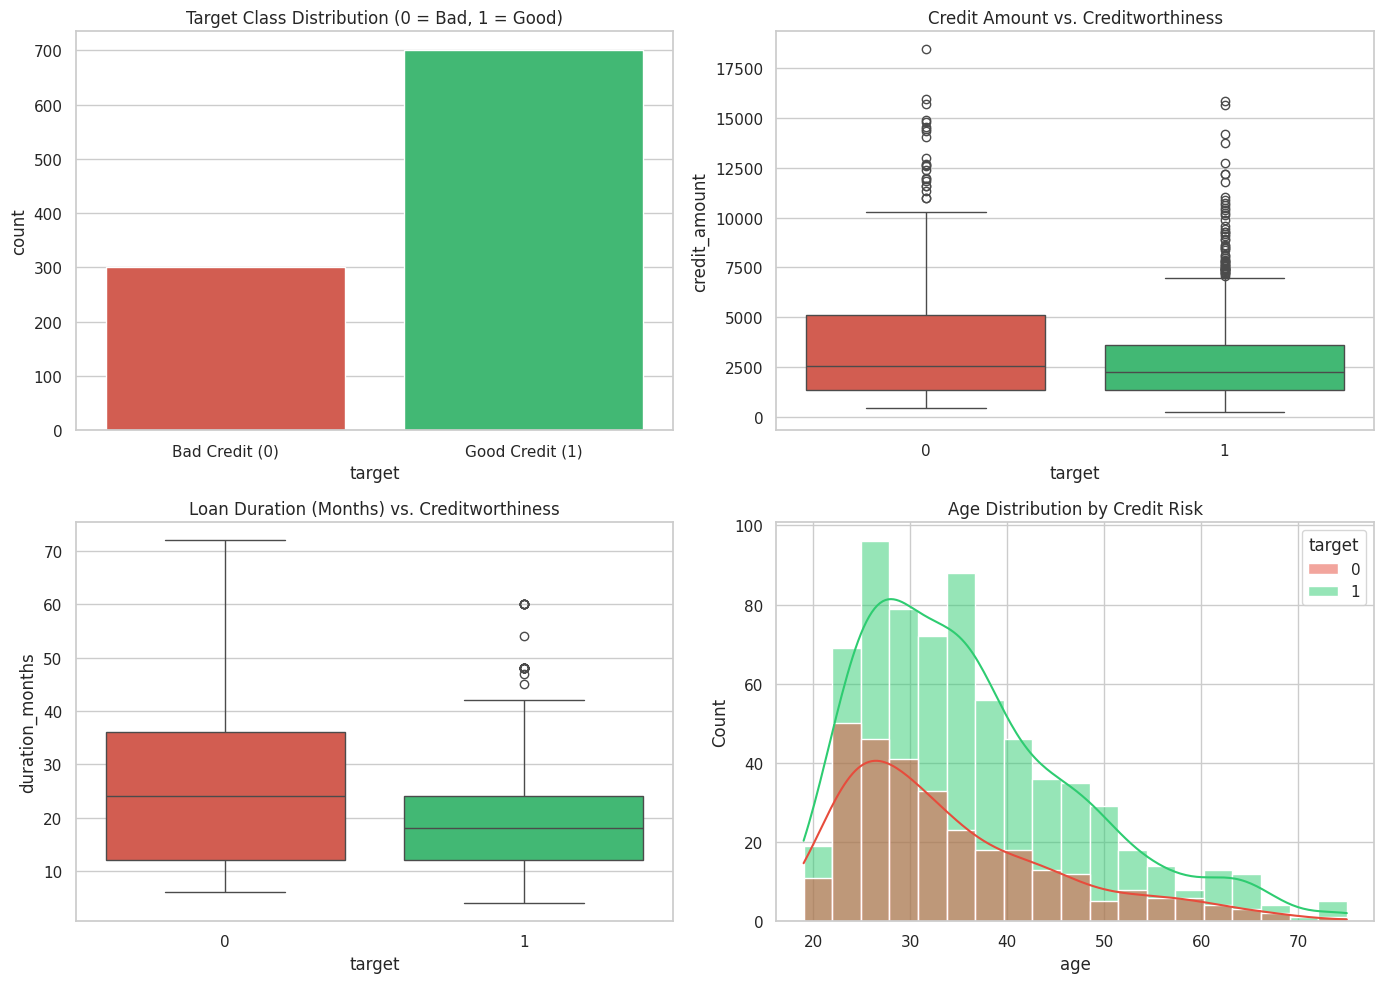

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution
sns.countplot(x='target', data=df, ax=axes[0, 0], palette=['#e74c3c', '#2ecc71'])
axes[0, 0].set_title('Target Class Distribution (0 = Bad, 1 = Good)')
axes[0, 0].set_xticklabels(['Bad Credit (0)', 'Good Credit (1)'])

# 2. Credit Amount Distribution by Target
sns.boxplot(x='target', y='credit_amount', data=df, ax=axes[0, 1], palette=['#e74c3c', '#2ecc71'])
axes[0, 1].set_title('Credit Amount vs. Creditworthiness')

# 3. Duration in Months by Target
sns.boxplot(x='target', y='duration_months', data=df, ax=axes[1, 0], palette=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Loan Duration (Months) vs. Creditworthiness')

# 4. Age Distribution by Target
sns.histplot(data=df, x='age', hue='target', kde=True, ax=axes[1, 1], palette=['#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Age Distribution by Credit Risk')

plt.tight_layout()
plt.show()

In [9]:
# Create engineered financial ratios
df['monthly_installment'] = df['credit_amount'] / df['duration_months']
df['credit_to_age_ratio'] = df['credit_amount'] / df['age']
df['credit_per_existing_credit'] = df['credit_amount'] / df['existing_credits']

print("New engineered features added successfully!")
df[['credit_amount', 'duration_months', 'monthly_installment', 'credit_to_age_ratio', 'credit_per_existing_credit']].head()

New engineered features added successfully!


,credit_amount,duration_months,monthly_installment,credit_to_age_ratio,credit_per_existing_credit
0,1169,6,194.833333,17.447761,584.5
1,5951,48,123.979167,270.500000,5951.0
2,2096,12,174.666667,42.775510,2096.0
3,7882,42,187.666667,175.155556,7882.0
4,4870,24,202.916667,91.886792,2435.0


In [10]:
# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features ({len(num_cols)}):", num_cols)
print(f"Categorical Features ({len(cat_cols)}):", cat_cols)

# Define Preprocessing Pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

Numerical Features (10): ['duration_months', 'credit_amount', 'installment_rate', 'present_residence_since', 'age', 'existing_credits', 'liable_people', 'monthly_installment', 'credit_to_age_ratio', 'credit_per_existing_credit']
Categorical Features (13): ['account_status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit preprocessor on X_train ONLY, then transform X_train and X_test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"X_train shape: {X_train_prep.shape}")
print(f"X_test shape:  {X_test_prep.shape}")
print(f"y_train class distribution:\n{y_train.value_counts(normalize=True)}")

X_train shape: (800, 64)
X_test shape:  (200, 64)
y_train class distribution:
target
1    0.7
0    0.3
Name: proportion, dtype: float64


In [12]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results_list = []

# Loop over models, train, predict, and collect metrics
for name, model in models.items():
    model.fit(X_train_prep, y_train)
    y_pred = model.predict(X_test_prep)
    y_proba = model.predict_proba(X_test_prep)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

# Display Results Table
results_df = pd.DataFrame(results_list)
display(results_df.style.highlight_max(axis=0, color='lightgreen'))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.720000,0.783784,0.828571,0.805556,0.762143
1,Decision Tree,0.655000,0.751773,0.757143,0.754448,0.586905
2,Random Forest,0.750000,0.777778,0.900000,0.834437,0.779286


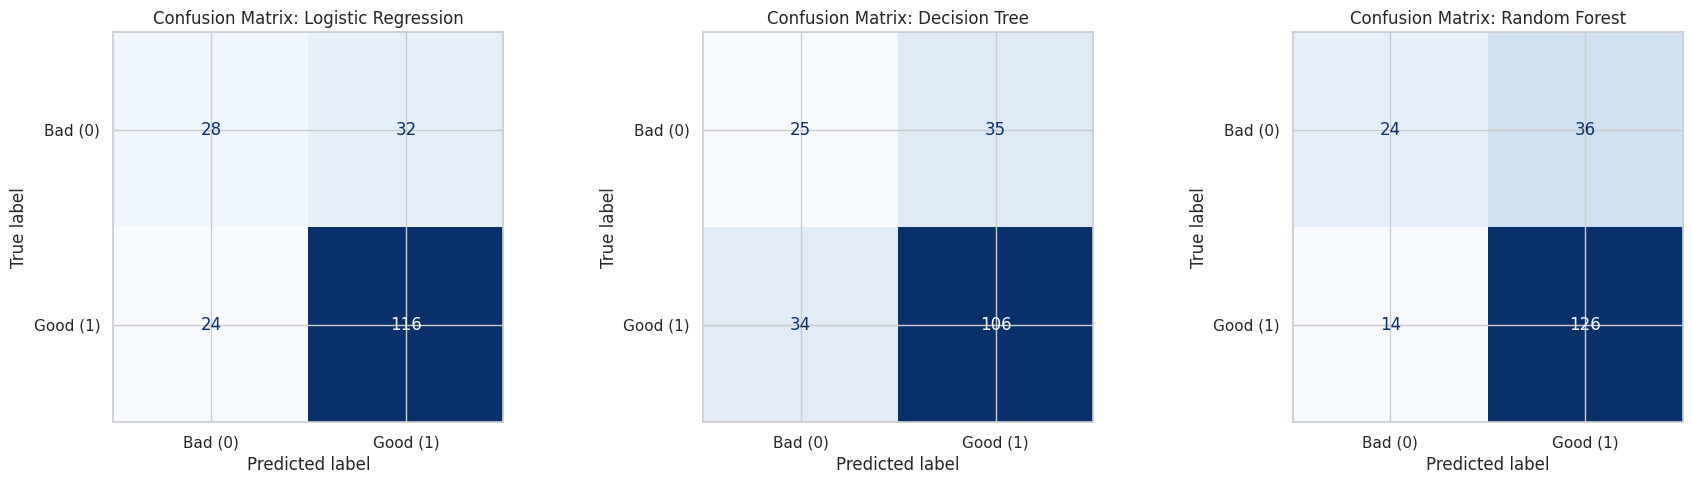

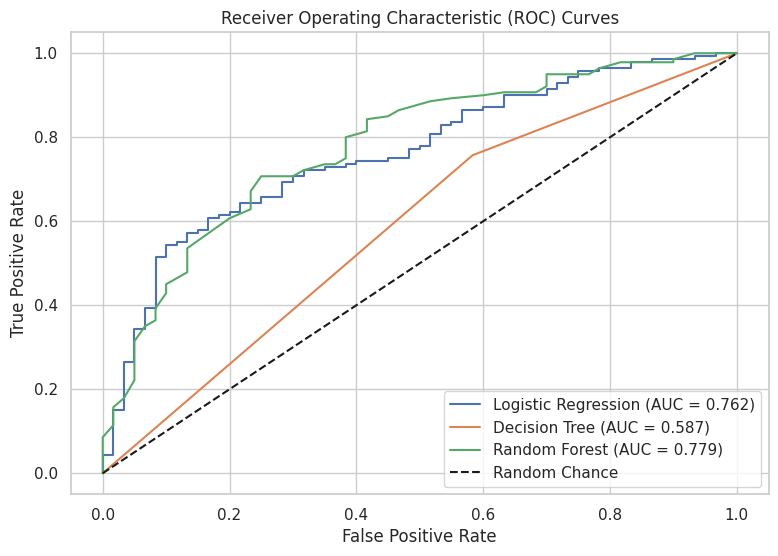

In [13]:
# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_prep)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad (0)', 'Good (1)'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()

# Plot ROC Curves
plt.figure(figsize=(9, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_prep)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

In [14]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_base = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_prep, y_train)

best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate Tuned Model
y_pred_tuned = best_rf.predict(X_test_prep)
y_proba_tuned = best_rf.predict_proba(X_test_prep)[:, 1]

print("\n--- Tuned Random Forest Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_tuned):.4f}")

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

--- Tuned Random Forest Metrics ---
Accuracy:  0.7800
Precision: 0.7927
Recall:    0.9286
F1-Score:  0.8553
ROC-AUC:   0.7900


/tmp/ipykernel_3232/2265059730.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')


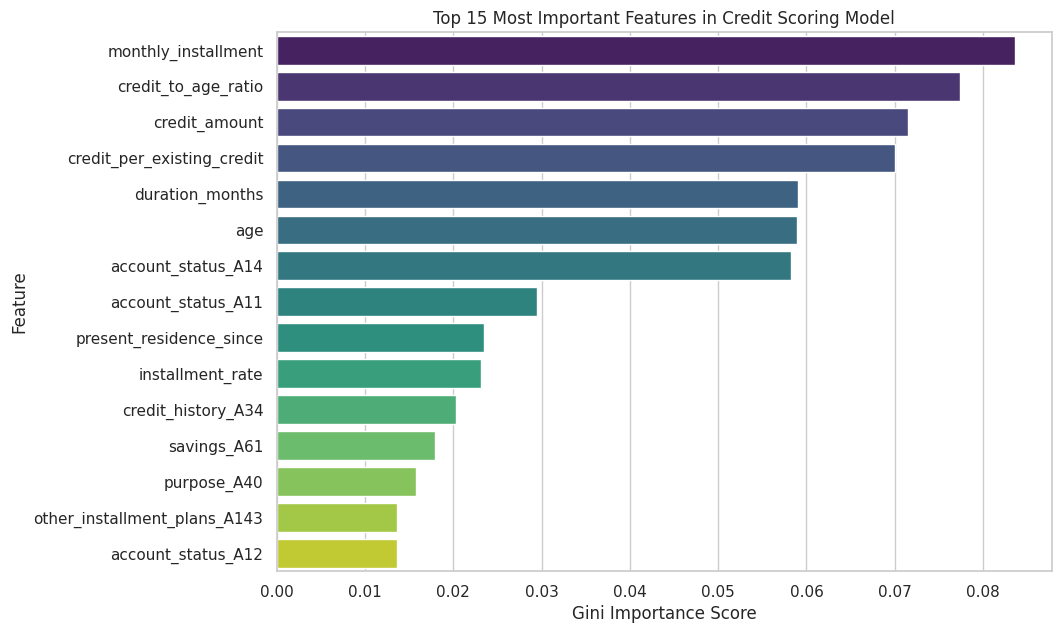

In [15]:
# Extract feature names after One-Hot Encoding
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(encoded_cat_cols)

# Extract importances
importances = best_rf.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Features
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features in Credit Scoring Model')
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature')
plt.show()

In [16]:
def predict_applicant_creditworthiness(raw_applicant_dict, preprocessor, model):
    """
    Accepts raw dictionary input of an applicant, preprocesses, and returns credit risk.
    """
    # Convert dictionary to DataFrame
    input_df = pd.DataFrame([raw_applicant_dict])

    # Apply Feature Engineering
    input_df['monthly_installment'] = input_df['credit_amount'] / input_df['duration_months']
    input_df['credit_to_age_ratio'] = input_df['credit_amount'] / input_df['age']
    input_df['credit_per_existing_credit'] = input_df['credit_amount'] / input_df['existing_credits']

    # Preprocess using fitted ColumnTransformer
    input_prep = preprocessor.transform(input_df)

    # Make Prediction
    pred_class = model.predict(input_prep)[0]
    pred_prob = model.predict_proba(input_prep)[0]

    status = "GOOD CREDIT (Low Risk)" if pred_class == 1 else "BAD CREDIT (High Risk)"
    confidence = pred_prob[pred_class] * 100

    print("=== APPLICANT CREDIT ASSESSMENT ===")
    print(f"Prediction Result:  {status}")
    print(f"Confidence Score:   {confidence:.2f}%")
    print(f"Probability (Good): {pred_prob[1]:.4f}")
    print(f"Probability (Bad):  {pred_prob[0]:.4f}")
    print("===================================")

# Example Sample Applicant Data
sample_applicant = {
    'account_status': 'A11',             # < 0 DM checking balance
    'duration_months': 24,
    'credit_history': 'A32',             # Existing credits paid back duly
    'purpose': 'A40',                    # Car (new)
    'credit_amount': 4870,
    'savings': 'A61',                    # < 100 DM savings
    'employment_duration': 'A73',        # 1 to 4 years employed
    'installment_rate': 3,
    'personal_status_sex': 'A93',        # Male single
    'other_debtors': 'A101',             # None
    'present_residence_since': 2,
    'property': 'A121',                  # Real estate
    'age': 35,
    'other_installment_plans': 'A143',   # None
    'housing': 'A152',                   # Owns home
    'existing_credits': 2,
    'job': 'A173',                       # Skilled employee
    'liable_people': 1,
    'telephone': 'A191',                 # None
    'foreign_worker': 'A201'             # Yes
}

# Run sample test
predict_applicant_creditworthiness(sample_applicant, preprocessor, best_rf)

=== APPLICANT CREDIT ASSESSMENT ===
Prediction Result:  BAD CREDIT (High Risk)
Confidence Score:   57.72%
Probability (Good): 0.4228
Probability (Bad):  0.5772
